<a href="https://colab.research.google.com/github/WizardsugarGG/MINERIA-DE-DATOS/blob/main/PROYECTO_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROYECTO 3
### MARQUEZ PINEDA IGNACIO

Una institución educativa y administrativa recibe diariamente una gran cantidad de correos electrónicos. Algunos mensajes son relevantes para actividades académicas y de gestión, mientras que otros corresponden a promociones, publicidad engañosa o mensajes no deseados. El objetivo del proyecto es analizar un conjunto de correos etiquetados para construir un modelo que permita distinguir entre mensajes legítimos y mensajes de spam.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import warnings

In [2]:
df = pd.read_csv("CORREOS_ELECTRONICOS.csv")
df

,"ID,Correo,Clase"
0,"M01,""gana dinero rapido con esta oferta exclus..."
1,"M02,""felicidades has sido seleccionado para pr..."
2,"M03,""oferta limitada compra hoy y recibe bono""..."
3,"M04,""haz clic ahora para reclamar tu descuento..."
4,"M05,""promocion especial gana premio en minutos..."
5,"M06,""gratis acceso premium por tiempo limitado..."
6,"M07,""recibe dinero facil con esta oportunidad""..."
7,"M08,""oferta urgente ultimo dia para ganar"",spam"
8,"M09,""bono exclusivo para nuevos usuarios regis..."
9,"M10,""premio garantizado reclama tu regalo grat..."


In [6]:
# CORREGIR FORMATO DEL CSV
# ============================================

# El archivo viene en una sola columna
df = df.iloc[:,0].str.extract(r'(M\d+),"(.*?)",(.*)')

# Renombrar columnas
df.columns = ['ID', 'Correo', 'Clase']

# Mostrar información
print(df.head())
print(df.info())

    ID                                             Correo Clase
0  M01       gana dinero rapido con esta oferta exclusiva  spam
1  M02  felicidades has sido seleccionado para premio ...  spam
2  M03           oferta limitada compra hoy y recibe bono  spam
3  M04          haz clic ahora para reclamar tu descuento  spam
4  M05          promocion especial gana premio en minutos  spam
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      24 non-null     object
 1   Correo  24 non-null     object
 2   Clase   24 non-null     object
dtypes: object(3)
memory usage: 708.0+ bytes
None


Clase
spam       12
no_spam    12
Name: count, dtype: int64


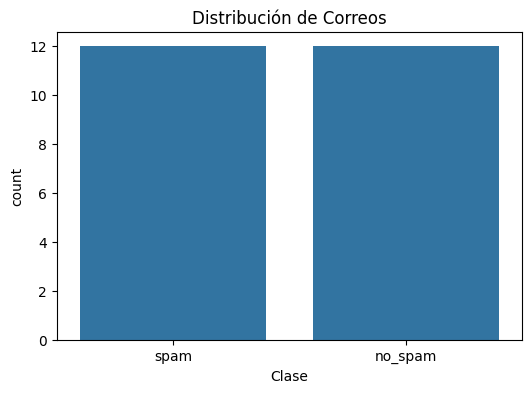

In [7]:
# ANÁLISIS EXPLORATORIO
# ============================================

# Cantidad de clases
print(df['Clase'].value_counts())

# Gráfico de distribución
plt.figure(figsize=(6,4))
sns.countplot(x='Clase', data=df)
plt.title("Distribución de Correos")
plt.show()


In [8]:
# LIMPIEZA DE TEXTO
# ============================================

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'[^a-záéíóúñ\s]', '', texto)
    texto = re.sub(r'\s+', ' ', texto)
    return texto

df['Correo_limpio'] = df['Correo'].apply(limpiar_texto)

print(df[['Correo','Correo_limpio']].head())

                                              Correo  \
0       gana dinero rapido con esta oferta exclusiva   
1  felicidades has sido seleccionado para premio ...   
2           oferta limitada compra hoy y recibe bono   
3          haz clic ahora para reclamar tu descuento   
4          promocion especial gana premio en minutos   

                                       Correo_limpio  
0       gana dinero rapido con esta oferta exclusiva  
1  felicidades has sido seleccionado para premio ...  
2           oferta limitada compra hoy y recibe bono  
3          haz clic ahora para reclamar tu descuento  
4          promocion especial gana premio en minutos  


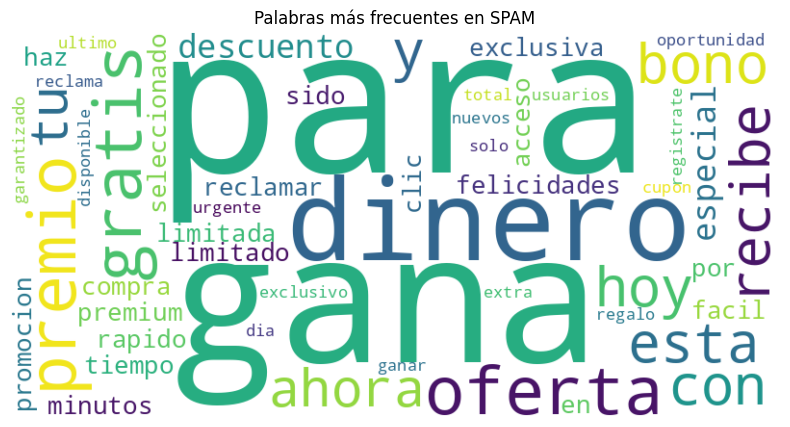

In [9]:
# WORDCLOUD SPAM
# ============================================

spam_texto = " ".join(df[df['Clase']=='spam']['Correo_limpio'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(spam_texto)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Palabras más frecuentes en SPAM")
plt.show()

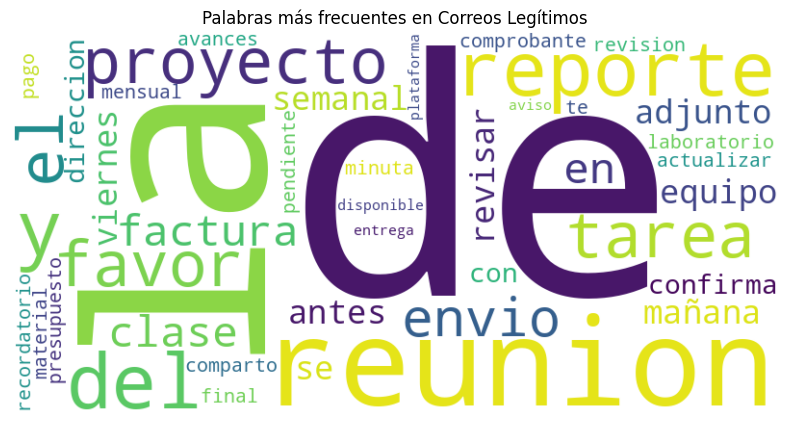

In [10]:
# WORDCLOUD HAM (LEGÍTIMOS)
# ============================================

ham_texto = " ".join(df[df['Clase']=='no_spam']['Correo_limpio'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(ham_texto)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Palabras más frecuentes en Correos Legítimos")
plt.show()

In [12]:
# PREPARACIÓN DEL MODELO
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Variables
X = df['Correo_limpio']
y = df['Clase']

# Vectorización
vectorizador = TfidfVectorizer()

X_vect = vectorizador.fit_transform(X)

# División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X_vect,
    y,
    test_size=0.2,
    random_state=42
)


In [13]:
# ENTRENAMIENTO DEL MODELO
# ============================================

modelo = MultinomialNB()

modelo.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)

Accuracy: 1.0

Reporte de Clasificación:

              precision    recall  f1-score   support

     no_spam       1.00      1.00      1.00         2
        spam       1.00      1.00      1.00         3

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



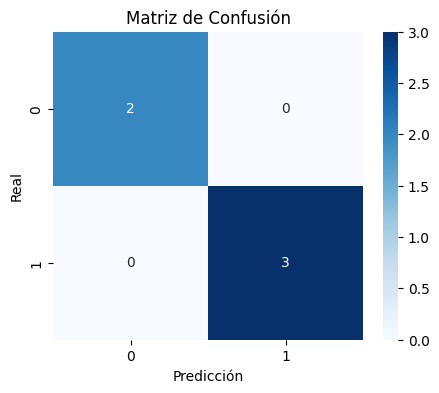

In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nReporte de Clasificación:\n")
print(classification_report(y_test, y_pred))

# Matriz de confusión
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [15]:
# PRUEBA MANUAL
# ============================================

nuevo_correo = ["felicidades has ganado un premio gratis"]

nuevo_correo = [limpiar_texto(texto) for texto in nuevo_correo]

nuevo_vect = vectorizador.transform(nuevo_correo)

prediccion = modelo.predict(nuevo_vect)

print("Clasificación:", prediccion[0])

Clasificación: spam


#CONCLUSIONES

El análisis realizado permitió identificar diferencias claras entre los correos legítimos (ham) y los correos no deseados (spam), observándose patrones específicos en el contenido textual de cada categoría.


Mediante el proceso de limpieza y transformación del texto, se logró preparar adecuadamente la información para el entrenamiento del modelo de Machine Learning, eliminando caracteres innecesarios y normalizando los mensajes.


Las nubes de palabras ayudaron a visualizar los términos más frecuentes en los mensajes spam, donde predominaron palabras relacionadas con promociones, premios, ofertas y publicidad engañosa.


En los correos legítimos aparecieron términos más asociados con actividades académicas y administrativas.


El modelo de clasificación utilizando Scikit-learn y el algoritmo Naive Bayes mostró un buen desempeño para distinguir entre mensajes legítimos y spam, alcanzando un nivel alto de precisión y exactitud.


La matriz de confusión y las métricas de evaluación permitieron comprobar que el sistema puede clasificar correctamente la mayoría de los correos, reduciendo errores en la detección de spam.


Este proyecto demuestra que las técnicas de procesamiento de lenguaje natural (NLP) y aprendizaje automático pueden aplicarse de manera efectiva en instituciones educativas y administrativas para mejorar la organización del correo electrónico y disminuir riesgos asociados a mensajes maliciosos o no deseados.